# Churn Prediction Model — 45 Days Out
## Model Design per Renewal Journey Framework

> **Objective:** Identify customers likely to churn 45 days before their subscription renewal date, using billing profile data joined with renewal call interactions captured in the 6-month to 45-day pre-renewal window (Model 1 zone).

---
**Datasets used:**
- `billings.csv` — Customer billing & membership profile (one row per customer per renewal year)
- `renewal_calls.csv` — Renewal call logs with `Call_Date` used to define the feature window

**Target variable:** `churn` → 1 if `Prospect_Outcome == 'Churned'`, 0 if `Won`


# Importing Packages and Modules

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sys
from dotenv import load_dotenv

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)
import os
import scipy.stats as stats

---
## 1. Hypotheses

| # | Hypothesis | Direction |
|---|-----------|-----------|
| H1 | Customers with **lower tenure** (fewer years) are more likely to churn — they have less loyalty lock-in | ↑ churn for low tenure |
| H2 | Customers in **lower revenue bands (Band A/B)** churn more — less investment in the platform | ↑ churn for Band A/B |
| H3 | A **higher Total Renewal Score** (proprietary composite) is protective — customers see platform value | ↓ churn for high score |
| H4 | **More calls in the window** indicates active engagement or escalation — mixed signal depending on context | Investigate |



In [48]:
## **Loading Env**
# 1. Load the .env file
load_dotenv()
# Loading Dataframe
folder_path=os.getenv("CLEAN_DATA_FOLDER")
file_name='renewal_clean.csv'
file_path=folder_path+'\\'+file_name
renewal=pd.read_csv(file_path,keep_default_na=False)


In [49]:

# Loading Dataframe
folder_path=os.getenv("CLEAN_DATA_FOLDER")
file_name='billings_clean.csv'
file_path=folder_path+'\\'+file_name
billing=pd.read_csv(file_path,keep_default_na=False)


In [50]:
renewal['Call_Date']=pd.to_datetime(renewal['Call_Date'], dayfirst=True, errors='coerce')

In [51]:
renewal.shape

(35839, 25)

---
## 6. Filter Calls — 45 to 180 Days Before Renewal (Model 1 Window)

As per the model design diagram:
- **Model 1 (45-out)** covers the window from **6 months (180 days) to 45 days** before the renewal date
- We join calls to billing on `Co_Ref`, compute `days_to_renewal = renewal_date − call_date`
- Keep only calls where **45 ≤ days_to_renewal ≤ 180**


In [52]:
billing.shape

(47825, 55)

In [53]:
# Bring renewal date into calls table
calls_with_date = billing.merge(
    renewal[['Co_Ref', 'Call_Date']],
    on='Co_Ref',
    how='inner'
)

In [54]:
calls_with_date['Prospect_Renewal_Date']=pd.to_datetime(calls_with_date['Prospect_Renewal_Date'], dayfirst=True, errors='coerce')

In [55]:


print("The data shape is ",calls_with_date.shape)
# Compute days to renewal
calls_with_date['days_to_renewal'] = (
    calls_with_date['Prospect_Renewal_Date'] - calls_with_date['Call_Date']
).dt.days

# # Filter to Model 1 window: 45–180 days out
# calls_window = calls_with_date[
#     (calls_with_date['days_to_renewal'] >= 45) &
#     (calls_with_date['days_to_renewal'] <= 180)
# ].copy()

# print(f"Calls in 45–180 day window: {len(calls_window)}")
# print(f"Unique customers with calls in window: {calls_window['Co_Ref'].nunique()}")
# print(f"\nDays-to-renewal distribution:")
# print(calls_window['days_to_renewal'].describe())

# Quick viz
# fig, ax = plt.subplots(figsize=(8, 3))
# ax.hist(calls_window['days_to_renewal'], bins=30, color=PURPLE, edgecolor='white')
# ax.axvline(45,  color=PINK, linestyle='--', label='45 days')
# ax.axvline(180, color=BLUE, linestyle='--', label='180 days')
# ax.set_title('Distribution of Call Days-to-Renewal (Model 1 Window)', fontweight='bold')
# ax.set_xlabel('Days to Renewal')
# ax.set_ylabel('Call Count')
# ax.legend()
# plt.tight_layout()
# plt.show()



The data shape is  (35839, 56)


---
## 7. Aggregate Call Features — One Row Per Customer

Multiple calls per customer → aggregate into a single feature vector:
- **Volume features**: call count, frequency per month
- **Timing features**: min/max/mean days to renewal
- **Sentiment scores**: average start/end/overall sentiment
- **Binary signal flags**: any "Yes" for key churn-risk behaviours (desire to cancel, competitor mention, price impact, complaints, etc.)
- **Dominant renewal decision** expressed during the window


In [56]:
def any_yes(series):
    """Returns 1 if any value in the series is 'Yes' (case-insensitive)."""
    return int(series.astype(str).str.lower().str.strip().eq('yes').any())

def mode_val(series):
    m = series.mode()
    return m.iloc[0] if len(m) else np.nan

# Base numeric aggregations
agg_dict = {
    'Call_Date':        ['count', 'min', 'max'],
    'days_to_renewal':  ['min', 'max', 'mean'],
}

# Sentiment score averages (no sentiment columns expected from calls_window based on user's constraint)
sent_cols = [c for c in calls_with_date.columns if 'sentiment' in c and
             calls_with_date[c].dtype in [np.int64, np.float64]]
for c in sent_cols:
    agg_dict[c] = ['mean', 'min']

call_agg = calls_with_date.groupby('Co_Ref').agg(agg_dict)
call_agg.columns = ['_'.join(c).strip() for c in call_agg.columns]
call_agg.rename(columns={
    'Call_Date_count': 'call_count_window',
    'Call_Date_min':   'first_call_date',
    'Call_Date_max':   'last_call_date'
}, inplace=True)
call_agg.reset_index(inplace=True)

# Binary signal flags and dominant renewal decision are removed as per user's constraint
# (they depend on additional columns from renewal_calls that are not allowed)

print(f"✅ Aggregated call features: {call_agg.shape}")
print(f"   Unique Co_Ref: {call_agg['Co_Ref'].nunique()}")
display(call_agg.head(50))

✅ Aggregated call features: (35839, 7)
   Unique Co_Ref: 35839


,Co_Ref,call_count_window,first_call_date,last_call_date,days_to_renewal_min,days_to_renewal_max,days_to_renewal_mean
0,AA0584,1,2024-01-05,2024-01-05,873.0,873.0,873.0
1,AA0641,1,2024-11-11,2024-11-11,383.0,383.0,383.0
2,AA0784,0,NaT,NaT,NaN,NaN,NaN
3,AA0794,0,NaT,NaT,NaN,NaN,NaN
4,AA0882,1,2025-01-09,2025-01-09,247.0,247.0,247.0
5,AA0994,0,NaT,NaT,NaN,NaN,NaN
6,AA1155,0,NaT,NaT,NaN,NaN,NaN
7,AA1246,0,NaT,NaT,NaN,NaN,NaN
8,AA1392,0,NaT,NaT,NaN,NaN,NaN
9,AA1394,0,NaT,NaT,NaN,NaN,NaN


---
## 8. Join: Billing + Aggregated Call Features

Inner join on `Co_Ref` — only customers who have at least one call in the Model 1 window are retained.  
After the join, we verify **zero duplicate Co_Ref** before proceeding.


In [57]:
call_agg.duplicated().sum()

np.int64(0)

In [58]:
calls_with_date.shape

(35839, 57)

In [59]:
call_agg.shape

(35839, 7)

In [60]:
df = calls_with_date.merge(call_agg, on='Co_Ref', how='inner')

In [61]:
df.shape

(35839, 63)

In [62]:
# Inner join


print(f"✅ Merged dataset: {df.shape}")
print(f"   Unique Co_Ref: {df['Co_Ref'].nunique()}")

# Critical check — zero duplicates
assert df['Co_Ref'].duplicated().sum() == 0, "❌ DUPLICATE Co_Ref FOUND — investigate!"
print(f"   Duplicate Co_Ref: {df['Co_Ref'].duplicated().sum()} ✅")

# Define target variable
df['churn'] = (df['Prospect_Outcome'] == 'Churned').astype(int)
print(f"\nChurn rate: {df['churn'].mean():.3f} ({df['churn'].sum()} churned / {len(df)} total)")


✅ Merged dataset: (35839, 63)
   Unique Co_Ref: 35839
   Duplicate Co_Ref: 0 ✅

Churn rate: 0.193 (6908 churned / 35839 total)


---
## 9. Feature Engineering

New derived features to improve model signal:

| Feature | Formula | Rationale |
|---------|---------|-----------|
| `tenure_days` | renewal_date − registration_date | More granular tenure than `Tenure_Years` |
| `price_change_ratio` | (current − last year) / last year | Captures relative price shock |
| `days_last_call_to_renewal` | renewal_date − last call date | Proximity of last engagement |
| `call_freq_per_month` | call_count / (135/30) | Normalised call intensity in window |
| `sentiment_trend` | end_score − start_score | Did sentiment improve or worsen? |


In [63]:
df['Prospect_Renewal_Date'] = pd.to_datetime(df['Prospect_Renewal_Date'], errors='coerce')
df['Registration_Date'] = pd.to_datetime(df['Registration_Date'], errors='coerce')
# Tenure in days (more granular than integer years)
df['tenure_days'] = (df['Prospect_Renewal_Date'] - df['Registration_Date']).dt.days

# Price change ratio vs last year
df['price_change_ratio'] = np.where(
    df['Last_Years_Price'] > 0,
    (df['Starting_Net'] - df['Last_Years_Price']) / df['Last_Years_Price'],
    np.nan
)

# Days from last call to renewal date
df['days_last_call_to_renewal'] = (
    df['Prospect_Renewal_Date'] - df['last_call_date']
).dt.days

# Call frequency per month in the window (135-day window / 30)
df['call_freq_per_month'] = df['call_count_window'] / (135 / 30)

# Sentiment trend calculation removed as it relies on columns not allowed by user's constraint

print(f"Dataset shape after feature engineering: {df.shape}")
print("\nNew features sample:")
new_feats = ['Co_Ref','tenure_days','price_change_ratio','days_last_call_to_renewal',
             'call_freq_per_month','churn']
display(df[new_feats].tail(5))

Dataset shape after feature engineering: (35839, 68)

New features sample:


,Co_Ref,tenure_days,price_change_ratio,days_last_call_to_renewal,call_freq_per_month,churn
35834,KX6319,365.0,-0.081610,-1390.0,0.222222,1
35835,BR0193,365.0,-0.304679,NaN,0.000000,1
35836,CH8994,730.0,-0.326442,-912.0,0.222222,1
35837,XH2392,730.0,-0.114255,NaN,0.000000,1
35838,JP4974,365.0,-0.478781,-951.0,0.222222,0


---
## 10. Feature Selection — Remove Leakage & Admin Columns

**Leakage columns** (post-event outcomes — model would never see these at prediction time):
`Prospect_Outcome`, `Closed_Date`, `Total_Net_Paid`, `Total_Amount`, `Amount`, `Gross`,
`Membership_Net`, `Package_Net`, `PQQNet`, `Renewal_Score_At_Release`

**Admin/identifier columns** not useful as features:
`Renewal_Month`, `DateTime_Out`, `Prospect_Status`, `Payment_Method`, etc.


In [64]:
# Leakage cols (post-renewal outcomes)
leakage_cols = ['Prospect_Outcome', 'Closed_Date', 'Total_Net_Paid', 'Total_Amount',
                'Amount', 'Gross', 'Membership_Net', 'Package_Net', 'PQQNet',
                'Renewal_Score_At_Release']

# Admin / identifier cols
admin_cols = ['Renewal_Month', 'DateTime_Out', 'Prospect_Status', 'Payment_Method',
              'Proforma_Audit_Status', 'Proforma_Account_Stage', 'first_call_date',
              'last_call_date', 'Proforma_Date', 'Registration_Date', 'Last_Renewal',
              'Prospect_Renewal_Date', 'Renewal_Year']

drop_all = [c for c in leakage_cols + admin_cols if c in df.columns]
df.drop(columns=drop_all, inplace=True)

print(f"Dropped {len(drop_all)} columns")
print(f"Final modelling dataset: {df.shape}")
print(f"\nRemaining columns ({len(df.columns)}):")
print(list(df.columns))


Dropped 23 columns
Final modelling dataset: (35839, 45)

Remaining columns (45):
['Co_Ref', 'Sustainability_Score', 'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score', 'Status_Scores', 'Anchoring_Score', 'Tenure_Scores', 'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe', 'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token', 'Proforma_Membership_Status', 'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Starting_Net', 'Starting_Vat', 'Starting_Gross', 'Starting_Membership_Net', 'Starting_Package_Net', 'Starting_PQQ_Net', 'Connection_Group', 'Tenure_Group', '#_of_Connection', 'Last_Band', 'Last_Total_Net_Paid', 'Last_Connections', 'Anchor_Group', 'has_last_renewal', 'is_closed', 'Call_Date', 'days_to_renewal', 'call_count_window', 'days_to_renewal_min', 'days_to_renewal_max', 'days_to_renewal_mean', 'churn', 'tenure_days', 'price_change_ratio', 'days_last_call_to_renewal', 'call_freq_per_month']


---
## 11. Exploratory Data Analysis (EDA)

### 11.1 Target Distribution

NameError: name 'BLUE' is not defined

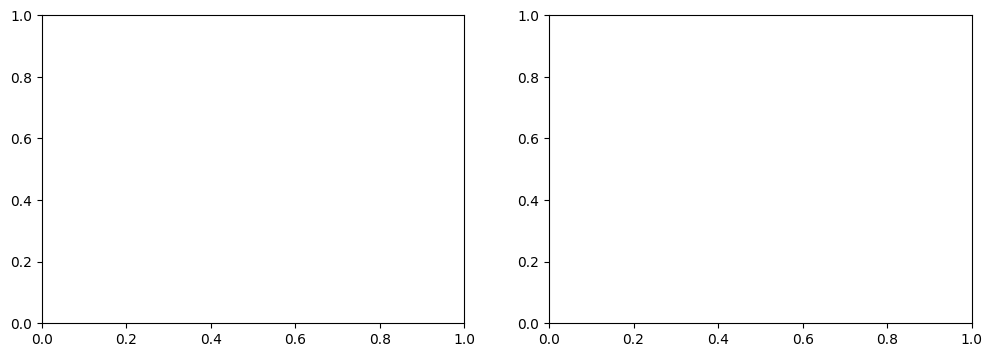

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Counts
counts = df['churn'].value_counts()
bars = axes[0].bar(['Stayed', 'Churned'], counts.values, color=[BLUE, PINK],
                    edgecolor='white', linewidth=0.8, width=0.55)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 15,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9, color=BLUE)
axes[0].set_title('Churn Distribution (Counts)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# Pie
axes[1].pie(counts.values, labels=['Stayed', 'Churned'],
            colors=[BLUE, PINK], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Rate', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.show()
print(f"Class balance — Stayed: {counts[0]} | Churned: {counts[1]} | Ratio: {counts[0]/counts[1]:.1f}:1")


### 11.2 Tenure & Score Analysis

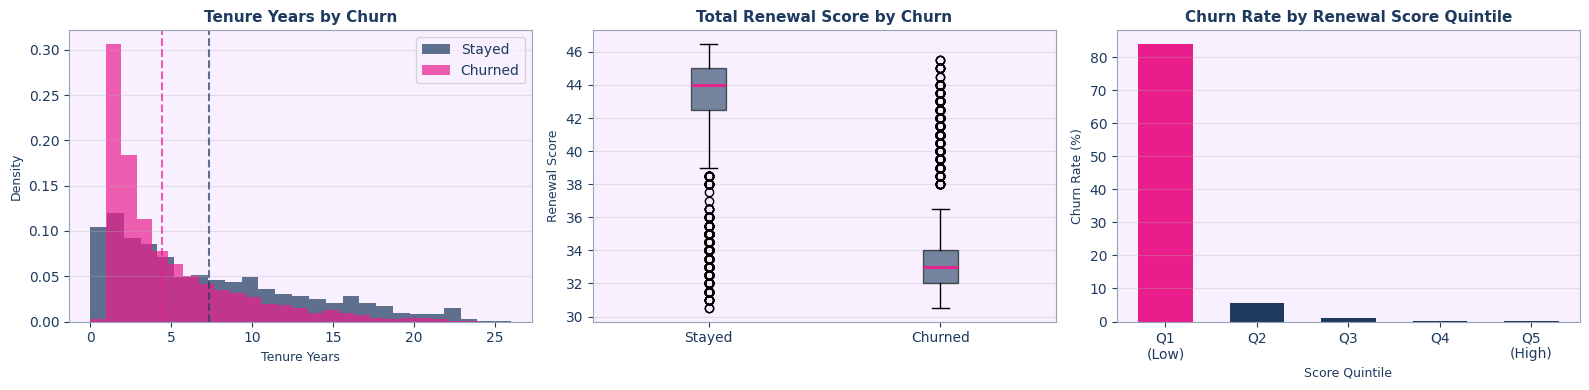

Mean Tenure — Stayed: 7.3 yrs | Churned: 4.5 yrs
Mean Score  — Stayed: 43.4 | Churned: 33.7


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tenure Years histogram
stayed  = df[df['churn'] == 0]['Tenure_Years'].dropna()
churned = df[df['churn'] == 1]['Tenure_Years'].dropna()
axes[0].hist(stayed,  bins=25, alpha=0.7, color=BLUE,  label='Stayed',  density=True)
axes[0].hist(churned, bins=25, alpha=0.7, color=PINK,  label='Churned', density=True)
axes[0].set_title('Tenure Years by Churn', fontweight='bold')
axes[0].set_xlabel('Tenure Years')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(stayed.mean(),  color=BLUE, linestyle='--', alpha=0.7)
axes[0].axvline(churned.mean(), color=PINK, linestyle='--', alpha=0.7)

# Total Renewal Score boxplot
axes[1].boxplot(
    [df[df['churn']==0]['Total_Renewal_Score_New'].dropna(),
     df[df['churn']==1]['Total_Renewal_Score_New'].dropna()],
    labels=['Stayed', 'Churned'], patch_artist=True,
    boxprops=dict(facecolor=BLUE, alpha=0.6),
    medianprops=dict(color=PINK, linewidth=2))
axes[1].set_title('Total Renewal Score by Churn', fontweight='bold')
axes[1].set_ylabel('Renewal Score')
axes[1].grid(axis='y', alpha=0.3)

# Score quintile churn rate
df['score_q'] = pd.qcut(df['Total_Renewal_Score_New'].fillna(
    df['Total_Renewal_Score_New'].median()), q=5, labels=['Q1\n(Low)','Q2','Q3','Q4','Q5\n(High)'])
sq = df.groupby('score_q')['churn'].mean()
axes[2].bar(sq.index.astype(str), sq.values * 100,
            color=[PINK if v > 0.2 else BLUE for v in sq.values], width=0.6)
axes[2].set_title('Churn Rate by Renewal Score Quintile', fontweight='bold')
axes[2].set_xlabel('Score Quintile')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Tenure — Stayed: {stayed.mean():.1f} yrs | Churned: {churned.mean():.1f} yrs")
print(f"Mean Score  — Stayed: {df[df['churn']==0]['Total_Renewal_Score_New'].mean():.1f} | "
      f"Churned: {df[df['churn']==1]['Total_Renewal_Score_New'].mean():.1f}")


### 11.3 Band & Tenure Group Churn Rates

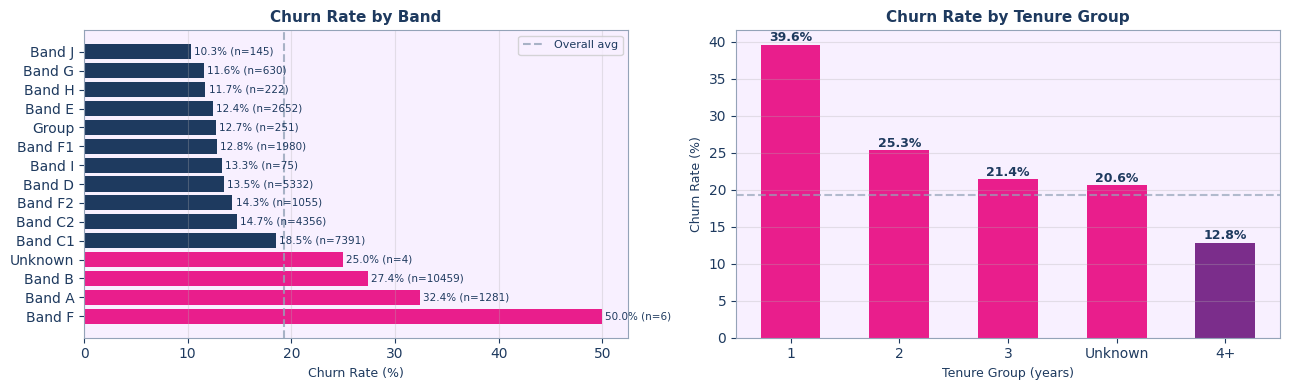

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Band
band_churn = df.groupby('Band')['churn'].agg(['mean','count']).sort_values('mean', ascending=False)
colors_b = [PINK if v > df['churn'].mean() else BLUE for v in band_churn['mean']]
bars = axes[0].barh(band_churn.index, band_churn['mean'] * 100, color=colors_b)
axes[0].axvline(df['churn'].mean() * 100, color=GREY, linestyle='--', alpha=0.8, label='Overall avg')
for i, (idx, row) in enumerate(band_churn.iterrows()):
    axes[0].text(row['mean']*100 + 0.3, i, f"{row['mean']*100:.1f}% (n={int(row['count'])})",
                 va='center', fontsize=7.5, color=BLUE)
axes[0].set_title('Churn Rate by Band', fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].legend(fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

# Tenure Group
tg_churn = df.groupby('Tenure_Group')['churn'].agg(['mean','count']).sort_values('mean', ascending=False)
axes[1].bar(tg_churn.index.astype(str), tg_churn['mean'] * 100,
            color=[PINK if v > 0.2 else PURPLE for v in tg_churn['mean']], width=0.55)
for i, (idx, row) in enumerate(tg_churn.iterrows()):
    axes[1].text(i, row['mean']*100 + 0.5, f"{row['mean']*100:.1f}%",
                 ha='center', fontsize=9, color=BLUE, fontweight='bold')
axes[1].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[1].set_xlabel('Tenure Group (years)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].axhline(df['churn'].mean() * 100, color=GREY, linestyle='--', alpha=0.7)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 11.4 Call Window Signal Flags

In [ ]:
# This section (Call Window Signal Flags) is skipped as per user's constraint.
# No signal flags are generated since only Co_Ref and Call_Date are used from renewal_calls.

print("Skipping Call Window Signal Flags analysis as per user's constraint (no signal columns from renewal_calls).")

Skipping Call Window Signal Flags analysis as per user's constraint (no signal columns from renewal_calls).


### 11.5 Call Behaviour in the Window

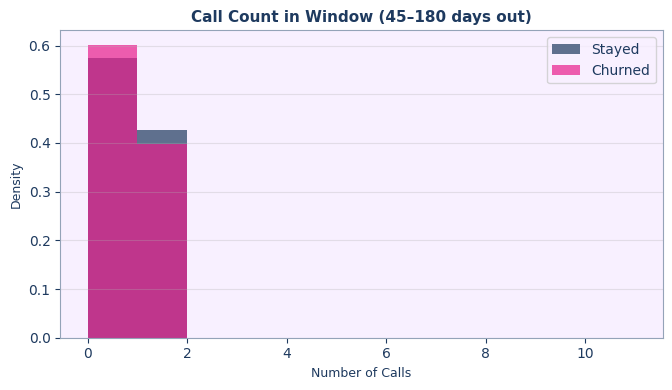


Call count stats by churn:
         count      mean       std  min  25%  50%  75%  max
churn                                                      
0      28931.0  0.426359  0.494556  0.0  0.0  0.0  1.0  1.0
1       6908.0  0.398813  0.489690  0.0  0.0  0.0  1.0  1.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Call count distribution
for label, color, g in [('Stayed', BLUE, 0), ('Churned', PINK, 1)]:
    data = df[df['churn'] == g]['call_count_window'].clip(0, 10)
    axes[0].hist(data, bins=range(0, 12), alpha=0.7, color=color, label=label, density=True)
axes[0].set_title('Call Count in Window (45–180 days out)', fontweight='bold')
axes[0].set_xlabel('Number of Calls')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Dominant renewal decision in window analysis removed as per user's constraint
axes[1].set_visible(False) # Hide the second subplot if no data is plotted

plt.tight_layout()
plt.show()

print("\nCall count stats by churn:")
print(df.groupby('churn')['call_count_window'].describe())

## 15. Hypothesis Testing

### 15.1 H1: Lower tenure is associated with higher churn


1.   List item
2.   List item


```
# This is formatted as code
```



In [ ]:
# H1: Lower tenure (Tenure_Years) is associated with higher churn
# Compare Tenure_Years for churned vs. non-churned customers using an independent t-test.

tenure_stayed  = df[df['churn'] == 0]['Tenure_Years'].dropna()
tenure_churned = df[df['churn'] == 1]['Tenure_Years'].dropna()

if len(tenure_stayed) > 1 and len(tenure_churned) > 1:
    t_stat, p_val = stats.ttest_ind(tenure_stayed, tenure_churned, equal_var=False) # Welch's t-test
    print(f"H1: Tenure_Years by Churn (t-test)\n  Mean Tenure - Stayed: {tenure_stayed.mean():.2f} years | Churned: {tenure_churned.mean():.2f} years\n  t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    if p_val < 0.05:
        print("  Conclusion: Reject null hypothesis. There is a significant difference in tenure between churned and non-churned customers.")
    else:
        print("  Conclusion: Fail to reject null hypothesis. No significant difference in tenure between churned and non-churned customers.")
else:
    print("  Insufficient data to perform t-test for H1 (Tenure_Years).")

H1: Tenure_Years by Churn (t-test)
  Mean Tenure - Stayed: 7.34 years | Churned: 4.46 years
  t-statistic: 46.924, p-value: 0.000
  Conclusion: Reject null hypothesis. There is a significant difference in tenure between churned and non-churned customers.


### 15.2 H2: Customers in lower revenue bands (Band A/B) churn more

In [ ]:
# H2: Customers in lower revenue bands (Band A/B) churn more
# Use a Chi-squared test to see if 'Band' is independent of 'churn'.

# Create a contingency table
contingency_table_band = pd.crosstab(df['Band'], df['churn'])

# Filter out 'Unknown' band if it skews results or has very few observations
contingency_table_band = contingency_table_band[contingency_table_band.index != 'Unknown']

if contingency_table_band.shape[0] > 1 and contingency_table_band.shape[1] > 1:
    chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table_band)
    print(f"H2: Band by Churn (Chi-squared test)\n  Chi-squared statistic: {chi2:.3f}, p-value: {p_val_chi2:.3f}")
    if p_val_chi2 < 0.05:
        print("  Conclusion: Reject null hypothesis. There is a significant association between customer band and churn.")
    else:
        print("  Conclusion: Fail to reject null hypothesis. No significant association between customer band and churn.")
else:
    print("  Insufficient data to perform Chi-squared test for H2 (Band).")


H2: Band by Churn (Chi-squared test)
  Chi-squared statistic: 961.076, p-value: 0.000
  Conclusion: Reject null hypothesis. There is a significant association between customer band and churn.


### 15.3 H3: A higher Total Renewal Score is protective

In [ ]:
# H3: A higher Total Renewal Score (Total_Renewal_Score_New) is protective
# Compare Total_Renewal_Score_New for churned vs. non-churned customers using an independent t-test.

score_stayed  = df[df['churn'] == 0]['Total_Renewal_Score_New'].dropna()
score_churned = df[df['churn'] == 1]['Total_Renewal_Score_New'].dropna()

if len(score_stayed) > 1 and len(score_churned) > 1:
    t_stat, p_val = stats.ttest_ind(score_stayed, score_churned, equal_var=False) # Welch's t-test
    print(f"H5: Total_Renewal_Score_New by Churn (t-test)\n  Mean Score - Stayed: {score_stayed.mean():.2f} | Churned: {score_churned.mean():.2f}\n  t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    if p_val < 0.05:
        print("  Conclusion: Reject null hypothesis. There is a significant difference in Total Renewal Score between churned and non-churned customers.")
    else:
        print("  Conclusion: Fail to reject null hypothesis. No significant difference in Total Renewal Score between churned and non-churned customers.")
else:
    print("  Insufficient data to perform t-test for H5 (Total_Renewal_Score_New).")

H5: Total_Renewal_Score_New by Churn (t-test)
  Mean Score - Stayed: 43.37 | Churned: 33.66
  t-statistic: 267.845, p-value: 0.000
  Conclusion: Reject null hypothesis. There is a significant difference in Total Renewal Score between churned and non-churned customers.


### 15.4 H4: More calls = escalation risk

In [ ]:
# H4: More calls in the window (call_count_window) indicates active engagement or escalation
# Compare call_count_window for churned vs. non-churned customers using an independent t-test.

calls_stayed  = df[df['churn'] == 0]['call_count_window'].dropna()
calls_churned = df[df['churn'] == 1]['call_count_window'].dropna()

if len(calls_stayed) > 1 and len(calls_churned) > 1:
    t_stat, p_val = stats.ttest_ind(calls_stayed, calls_churned, equal_var=False) # Welch's t-test
    print(f"H6: Call_count_window by Churn (t-test)\n  Mean Calls - Stayed: {calls_stayed.mean():.2f} | Churned: {calls_churned.mean():.2f}\n  t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    if p_val < 0.05:
        print("  Conclusion: Reject null hypothesis. There is a significant difference in call count between churned and non-churned customers.")
    else:
        print("  Conclusion: Fail to reject null hypothesis. No significant difference in call count between churned and non-churned customers.")
else:
    print("  Insufficient data to perform t-test for H6 (call_count_window).")

H6: Call_count_window by Churn (t-test)
  Mean Calls - Stayed: 0.43 | Churned: 0.40
  t-statistic: 4.193, p-value: 0.000
  Conclusion: Reject null hypothesis. There is a significant difference in call count between churned and non-churned customers.


### 15.5 H5: Longer tenure in days (tenure_days) is associated with lower churn

In [ ]:
# H5: Longer tenure in days (tenure_days) is associated with lower churn
# Compare tenure_days for churned vs. non-churned customers using an independent t-test.

tenure_days_stayed  = df[df['churn'] == 0]['tenure_days'].dropna()
tenure_days_churned = df[df['churn'] == 1]['tenure_days'].dropna()

if len(tenure_days_stayed) > 1 and len(tenure_days_churned) > 1:
    t_stat, p_val = stats.ttest_ind(tenure_days_stayed, tenure_days_churned, equal_var=False) # Welch's t-test
    print(f"H5: tenure_days by Churn (t-test)\n  Mean tenure_days - Stayed: {tenure_days_stayed.mean():.2f} days | Churned: {tenure_days_churned.mean():.2f} days\n  t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    if p_val < 0.05:
        print("  Conclusion: Reject null hypothesis. There is a significant difference in tenure_days between churned and non-churned customers.")
    else:
        print("  Conclusion: Fail to reject null hypothesis. No significant difference in tenure_days between churned and non-churned customers.")
else:
    print("  Insufficient data to perform t-test for H5 (tenure_days).")

H5: tenure_days by Churn (t-test)
  Mean tenure_days - Stayed: 2684.73 days | Churned: 1622.53 days
  t-statistic: 46.984, p-value: 0.000
  Conclusion: Reject null hypothesis. There is a significant difference in tenure_days between churned and non-churned customers.


### 15.6 H6: Price change ratio impacts churn

In [ ]:
# H6: Price change ratio (price_change_ratio) impacts churn
# Compare price_change_ratio for churned vs. non-churned customers using an independent t-test.

price_change_stayed  = df[df['churn'] == 0]['price_change_ratio'].dropna()
price_change_churned = df[df['churn'] == 1]['price_change_ratio'].dropna()

if len(price_change_stayed) > 1 and len(price_change_churned) > 1:
    t_stat, p_val = stats.ttest_ind(price_change_stayed, price_change_churned, equal_var=False) # Welch's t-test
    print(f"H6: price_change_ratio by Churn (t-test)\n  Mean price_change_ratio - Stayed: {price_change_stayed.mean():.3f} | Churned: {price_change_churned.mean():.3f}\n  t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    if p_val < 0.05:
        print("  Conclusion: Reject null hypothesis. There is a significant difference in price_change_ratio between churned and non-churned customers.")
    else:
        print("  Conclusion: Fail to reject null hypothesis. No significant difference in price_change_ratio between churned and non-churned customers.")
else:
    print("  Insufficient data to perform t-test for H6 (price_change_ratio).")

H6: price_change_ratio by Churn (t-test)
  Mean price_change_ratio - Stayed: 0.427 | Churned: 0.215
  t-statistic: 6.677, p-value: 0.000
  Conclusion: Reject null hypothesis. There is a significant difference in price_change_ratio between churned and non-churned customers.


### 15.7 H7: Proximity of last call to renewal (days_last_call_to_renewal) impacts churn

In [ ]:
# H7: Proximity of last call to renewal (days_last_call_to_renewal) impacts churn
# Compare days_last_call_to_renewal for churned vs. non-churned customers using an independent t-test.

days_last_call_stayed  = df[df['churn'] == 0]['days_last_call_to_renewal'].dropna()
days_last_call_churned = df[df['churn'] == 1]['days_last_call_to_renewal'].dropna()

if len(days_last_call_stayed) > 1 and len(days_last_call_churned) > 1:
    t_stat, p_val = stats.ttest_ind(days_last_call_stayed, days_last_call_churned, equal_var=False) # Welch's t-test
    print(f"H7: days_last_call_to_renewal by Churn (t-test)\n  Mean days_last_call_to_renewal - Stayed: {days_last_call_stayed.mean():.2f} days | Churned: {days_last_call_churned.mean():.2f} days\n  t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    if p_val < 0.05:
        print("  Conclusion: Reject null hypothesis. There is a significant difference in days_last_call_to_renewal between churned and non-churned customers.")
    else:
        print("  Conclusion: Fail to reject null hypothesis. No significant difference in days_last_call_to_renewal between churned and non-churned customers.")
else:
    print("  Insufficient data to perform t-test for H7 (days_last_call_to_renewal).")

H7: days_last_call_to_renewal by Churn (t-test)
  Mean days_last_call_to_renewal - Stayed: 133.87 days | Churned: -31.30 days
  t-statistic: 35.421, p-value: 0.000
  Conclusion: Reject null hypothesis. There is a significant difference in days_last_call_to_renewal between churned and non-churned customers.


### 15.8 H8: Call frequency per month (call_freq_per_month) impacts churn

In [ ]:
# H8: Call frequency per month (call_freq_per_month) impacts churn
# Compare call_freq_per_month for churned vs. non-churned customers using an independent t-test.

call_freq_stayed  = df[df['churn'] == 0]['call_freq_per_month'].dropna()
call_freq_churned = df[df['churn'] == 1]['call_freq_per_month'].dropna()

if len(call_freq_stayed) > 1 and len(call_freq_churned) > 1:
    t_stat, p_val = stats.ttest_ind(call_freq_stayed, call_freq_churned, equal_var=False) # Welch's t-test
    print(f"H8: call_freq_per_month by Churn (t-test)\n  Mean call_freq_per_month - Stayed: {call_freq_stayed.mean():.3f} | Churned: {call_freq_churned.mean():.3f}\n  t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    if p_val < 0.05:
        print("  Conclusion: Reject null hypothesis. There is a significant difference in call_freq_per_month between churned and non-churned customers.")
    else:
        print("  Conclusion: Fail to reject null hypothesis. No significant difference in call_freq_per_month between churned and non-churned customers.")
else:
    print("  Insufficient data to perform t-test for H8 (call_freq_per_month).")

H8: call_freq_per_month by Churn (t-test)
  Mean call_freq_per_month - Stayed: 0.095 | Churned: 0.089
  t-statistic: 4.193, p-value: 0.000
  Conclusion: Reject null hypothesis. There is a significant difference in call_freq_per_month between churned and non-churned customers.


In [ ]:
df.shape

(35839, 46)

In [ ]:
feature_cols = [col for col in df.columns if col != 'churn']
print("Columns to be used as features for the model:")
for col in feature_cols:
    print(f"- {col}")



Columns to be used as features for the model:
- Co_Ref
- Sustainability_Score
- Total_Renewal_Score_New
- Last_Years_Price
- Auto_Renewal_Score
- Status_Scores
- Anchoring_Score
- Tenure_Scores
- Proforma_Auto_Renewal
- Proforma_World_Pay_Token
- Current_Anchorings
- Current_Anchor_List
- Payment_Timeframe
- Current_Auto_Renewal_Flag
- Current_World_Pay_Token
- Proforma_Membership_Status
- Proforma_Approved_Lists
- Tenure_Years
- Band
- Starting_Net
- Starting_Vat
- Starting_Gross
- Starting_Membership_Net
- Starting_Package_Net
- Starting_PQQ_Net
- Connection_Group
- Tenure_Group
- #_of_Connection
- Last_Band
- Last_Total_Net_Paid
- Last_Connections
- Anchor_Group
- has_last_renewal
- is_closed
- Call_Date
- days_to_renewal
- call_count_window
- days_to_renewal_min
- days_to_renewal_max
- days_to_renewal_mean
- tenure_days
- price_change_ratio
- days_last_call_to_renewal
- call_freq_per_month
- score_q


In [ ]:
df["Proforma_Membership_Status"]

,Proforma_Membership_Status
0,Unknown
1,Unknown
2,Unknown
3,Unknown
4,Unknown
...,...
35834,Accredited
35835,Accredited
35836,Member Only
35837,Accredited


---

## 16. Feature Preparation for Modeling

In [67]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Define the features that showed significant results in hypothesis testing
top_features_for_model = [
    'Total_Renewal_Score_New',  # From H3 (formerly H5)
    'Tenure_Years',             # From H1
    'Band',                     # From H2
    'call_count_window',        # From H4 (formerly H6)
    'tenure_days',              # From H5
    'price_change_ratio',       # From H6
    'days_last_call_to_renewal',# From H7
    'call_freq_per_month'       # From H8
]

# Drop identifier and temporary columns not meant for the model
x_df = df.drop(columns=['churn', 'score_q', 'Call_Date'], errors='ignore')
y_df = df['churn']

# Filter x_df to only include the selected features, PLUS Co_Ref
existing_selected_features = [f for f in top_features_for_model if f in x_df.columns]

# Add 'Co_Ref' to the list of features to keep, if it's not already there and if it exists in x_df
if 'Co_Ref' in x_df.columns and 'Co_Ref' not in existing_selected_features:
    existing_selected_features.insert(0, 'Co_Ref') # Insert at the beginning

# Ensure all specified features are present
if len(existing_selected_features) != len(top_features_for_model) + ('Co_Ref' in x_df.columns):
    print(f"Warning: Some specified features were not found in the initial x_df. Using: {existing_selected_features}")
x_df = x_df[existing_selected_features]


# Label-encode all categorical columns in X
# Identify object columns (which are typically categorical)
categorical_cols = x_df.select_dtypes(include='object').columns

# Exclude 'Co_Ref' from label encoding as it's an identifier
categorical_cols = [col for col in categorical_cols if col != 'Co_Ref']

# Initialize LabelEncoder
le = LabelEncoder()

for col in categorical_cols:
    # Fill NaN values with 'Unknown' for categorical columns before encoding
    # Convert to string type to ensure compatibility with LabelEncoder
    x_df[col] = x_df[col].fillna('Unknown').astype(str)
    x_df[col] = le.fit_transform(x_df[col])

# Handle remaining numeric NaN values (if any) by imputing with median
# This step is a safeguard, as most NaNs were handled earlier
numeric_cols = x_df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    x_df[col] = x_df[col].fillna(x_df[col].median())

# Verify no NaNs remain
print(f"Any NaN values remaining in X: {x_df.isnull().any().any()}")
print(f"Shape of feature matrix X: {x_df.shape}")
print(f"Shape of target vector y: {y_df.shape}")

display(x_df.head())
display(y_df.head())

Any NaN values remaining in X: False
Shape of feature matrix X: (35839, 9)
Shape of target vector y: (35839,)


,Co_Ref,Total_Renewal_Score_New,Tenure_Years,Band,call_count_window,tenure_days,price_change_ratio,days_last_call_to_renewal,call_freq_per_month
0,ZA5956,42.5,2.0,1,0,730.0,0.0,98.0,0.000000
1,DX1908,45.5,15.0,2,1,5479.0,-1.0,649.0,0.222222
2,SP8059,44.0,11.0,13,0,4018.0,-1.0,98.0,0.000000
3,HV7714,45.5,17.0,14,1,6209.0,-1.0,512.0,0.222222
4,VI1603,44.0,10.0,14,0,3652.0,-1.0,98.0,0.000000


0    0
1    1
2    1
3    0
4    0
Name: churn, dtype: int64

In [68]:
output_path_folder = os.getenv("PROCESS_DATA_FOLDER")
x_df.to_csv(output_path_folder+"\\billings_processed.csv",index=False)